# Paper plots


## Initialization and other utils
 

In [54]:
import ROOT
import os,sys,json
import argparse
from datetime import date    
import numpy as np
import copy
import math
import mplhep as hep
import matplotlib.pyplot as plt
ROOT.gROOT.SetBatch(1)
hep.style.use("CMS")

In [55]:
def getValues(histo):
    values = []
    bins = []
    for n in range(1, histo.GetNbinsX()+1):
        values.append(histo.GetBinContent(n))
        bins.append(histo.GetBinLowEdge(n))
    bins.append(histo.GetBinLowEdge(n) + histo.GetBinWidth(n))
    return np.array(values), np.array(bins)

## Specify plotting details

In [56]:
period = 'allYears'
includeSignal = True
#inDir = '/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Dec-11-2024_allYears_complete/' # Latest available
#inDir = '/ceph/cms/store/user/fernance/EXO-24-016/Spectra/FourMuon-noFourMuonAngularSelection/' # For check of OSV
#inDir = '/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Feb-20-2025_2023_noMasking'
inDir = '/ceph/cms/store/user/fernance/Run3ScoutingOutput/outputHistograms_Feb-25-2025_allYears'

samples = []
samples.append('Data')
"""
if includeSignal:
    #samples.append('Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-1.00mm')
    samples.append('Signal_HTo2ZdTo2mu2x_MZd-7p0_ctau-10.00mm')
    #samples.append('Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-100.00mm')
    #samples.append('Signal_BToPhi_MPhi-2p00_ctau-10.00mm')
    #samples.append('Signal_BToPhi_MPhi-4p00_ctau-100.00mm')
    samples.append('Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm')
    samples.append('Signal_ScenarioA_Mpi-4_MA-1p33_ctau-10.00mm')
    samples.append('Signal_ScenarioA_Mpi-10_MA-4p90_ctau-10.00mm')
    #samples.append('Signal_ScenarioB1_Mpi-2_MA-0p33_ctau-1.00mm')
    #samples.append('Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm')
    #samples.append('Signal_ScenarioB1_Mpi-5_MA-2p40_ctau-1.00mm')
    #samples.append('Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm')
    #samples.append('Signal_ScenarioB1_Mpi-5_MA-2p40_ctau-10.00mm')
"""

legnames = {}
legnames['Signal_BToPhi_MPhi-2p00_ctau-10.00mm']  = r"$B\rightarrow \phi X$: m = 2 GeV, $c\tau_{\phi} =$ 10 mm"
legnames['Signal_BToPhi_MPhi-4p00_ctau-100.00mm']  = r"$B\rightarrow \phi X$: m = 4 GeV, $c\tau_{\phi} =$ 100 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-2p0_ctau-1.00mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: $m_{Z_D}$ = 2 GeV, $c\tau_{{Z_{{D}}}} =$ 1 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-7p0_ctau-10.00mm']  = r"$h\rightarrow Z_{{D}}Z_{{D}}$: $m_{Z_D}$ = 7 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-10.00mm'] = r"$h\rightarrow Z_{{D}}Z_{{D}}$: $m_{Z_D}$ = 14 GeV, $c\tau_{{Z_{{D}}}} =$ 10 mm"
legnames['Signal_HTo2ZdTo2mu2x_MZd-14p0_ctau-100.00mm'] = r"$h\rightarrow Z_{{D}}Z_{{D}}$: $m_{Z_D}$ = 14 GeV, $c\tau_{{Z_{{D}}}} =$ 100 mm"
legnames['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-1.00mm'] = r"ScenarioA: $m_\pi = 5$ GeV, $m_A = 2.4$ GeV, $c\tau_{A} =$ 1 mm"
legnames['Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm'] = r"ScenarioA: $m_\pi = 5$ GeV, $m_A = 2.4$ GeV, $c\tau_{A} =$ 10 mm"
legnames['Signal_ScenarioA_Mpi-10_MA-4p90_ctau-10.00mm'] = r"ScenarioA: $m_\pi = 10$ GeV, $m_A = 4.9$ GeV, $c\tau_{A} =$ 10 mm"
legnames['Signal_ScenarioA_Mpi-4_MA-1p33_ctau-10.00mm'] = r"ScenarioA: $m_\pi = 4$ GeV, $m_A = 1.3$ GeV, $c\tau_{A} =$ 10 mm"
legnames['Signal_ScenarioB1_Mpi-2_MA-0p33_ctau-1.00mm'] = r"ScenarioB1: $m_\pi = 2$ GeV, $m_A = 0.33$ GeV, $c\tau_{\pi} =$ 1 mm"
legnames['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm'] = r"ScenarioB1: $m_\pi = 4$ GeV, $m_A = 1.33$ GeV, $c\tau_{\pi} =$ 1 mm"
legnames['Signal_ScenarioB1_Mpi-5_MA-2p40_ctau-1.00mm'] = r"ScenarioB1: $m_\pi = 5$ GeV, $m_A = 2.40$ GeV, $c\tau_{\pi} =$ 1 mm"
legnames['Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-10.00mm'] = r"ScenarioB1: $m_\pi = 4$ GeV, $m_A = 1.33$ GeV, $c\tau_{\pi} =$ 10 mm"
legnames['Signal_ScenarioB1_Mpi-5_MA-2p40_ctau-10.00mm'] = r"ScenarioB1: $m_\pi = 5$ GeV, $m_A = 2.40$ GeV, $c\tau_{\pi} =$ 10 mm"
                


#colors = ['#3f90da', '#ffa90e', '#bd1f01', '#94a4a2', '#832db6', '#a96b59']
#colors = ["#3f90da", "#ffa90e", "#bd1f01", "#94a4a2", "#832db6", "#a96b59", "#e76300", "#b9ac70", "#717581", "#92dadd"]
colors = ["#3f90da", "#ffa90e", "#bd1f01", "#832db6", "#e76300"]

## Invariant mass spectra

In [57]:
useNonPointing = False
useIso1PtHigh = False
useIso0PtHigh = False
useIso1PtLow = False
useIso0PtLow = False
useFourMuonOSV = False
useFourMuonSep = True

hnn = []
if useIso1PtHigh:
    hnn.append('d_Dimuon_lxy0p0to0p2_iso1_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy0p2to1p0_iso1_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy1p0to2p4_iso1_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy2p4to3p1_iso1_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy3p1to7p0_iso1_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy7p0to11p0_iso1_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy11p0to16p0_iso1_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy16p0to70p0_iso1_pthigh_rawmass')
if useIso0PtHigh:
    hnn.append('d_Dimuon_lxy0p0to0p2_iso0_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy0p2to1p0_iso0_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy1p0to2p4_iso0_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy2p4to3p1_iso0_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy3p1to7p0_iso0_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy7p0to11p0_iso0_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy11p0to16p0_iso0_pthigh_rawmass')
    hnn.append('d_Dimuon_lxy16p0to70p0_iso0_pthigh_rawmass')
if useIso1PtLow:
    hnn.append('d_Dimuon_lxy0p0to0p2_iso1_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy0p2to1p0_iso1_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy1p0to2p4_iso1_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy2p4to3p1_iso1_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy3p1to7p0_iso1_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy7p0to11p0_iso1_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy11p0to16p0_iso1_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy16p0to70p0_iso1_ptlow_rawmass')
if useIso0PtLow:
    hnn.append('d_Dimuon_lxy0p0to0p2_iso0_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy0p2to1p0_iso0_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy1p0to2p4_iso0_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy2p4to3p1_iso0_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy3p1to7p0_iso0_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy7p0to11p0_iso0_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy11p0to16p0_iso0_ptlow_rawmass')
    hnn.append('d_Dimuon_lxy16p0to70p0_iso0_ptlow_rawmass')
if useNonPointing:
    hnn.append('d_Dimuon_lxy0p0to0p2_non-pointing_rawmass')
    hnn.append('d_Dimuon_lxy0p2to1p0_non-pointing_rawmass')
    hnn.append('d_Dimuon_lxy1p0to2p4_non-pointing_rawmass')
    hnn.append('d_Dimuon_lxy2p4to3p1_non-pointing_rawmass')
    hnn.append('d_Dimuon_lxy3p1to7p0_non-pointing_rawmass')
    hnn.append('d_Dimuon_lxy7p0to11p0_non-pointing_rawmass')
    hnn.append('d_Dimuon_lxy11p0to16p0_non-pointing_rawmass')
    hnn.append('d_Dimuon_lxy16p0to70p0_non-pointing_rawmass')
if useFourMuonOSV:
    hnn.append('d_FourMu_osv_rawmass')
    samples.append('Signal_ScenarioB1_Mpi-2_MA-0p33_ctau-1.00mm')
    samples.append('Signal_ScenarioB1_Mpi-4_MA-1p33_ctau-1.00mm')
    samples.append('Signal_ScenarioB1_Mpi-5_MA-2p40_ctau-1.00mm')
if useFourMuonSep:
    hnn.append('d_FourMu_sep_rawmass')
    samples.append('Signal_HTo2ZdTo2mu2x_MZd-7p0_ctau-10.00mm')
    samples.append('Signal_ScenarioA_Mpi-5_MA-2p40_ctau-10.00mm')
    samples.append('Signal_ScenarioA_Mpi-4_MA-1p33_ctau-10.00mm')
    samples.append('Signal_ScenarioA_Mpi-10_MA-4p90_ctau-10.00mm')
#hnn.append('d_FourMu_osv_rawmass')
#hnn.append('d_FourMu_sep_rawmass')


In [58]:
# Create structure
histograms = {}
for hn in hnn:
    histograms[hn] = {}
    histograms[hn]['Data'] = 0.0
    histograms[hn]['Signal'] = {}
    for sample in samples:
        if 'Signal' not in sample:
            continue
        histograms[hn]['Signal'][sample] = 0.0
        
# Fill histograms
for sample in samples:
    tfile = ROOT.TFile('%s/histograms_%s_%s_all.root'%(inDir, sample, period))
    for hn in hnn:
        th1f = tfile.Get(hn)
        if 'Data'==sample:
            histograms[hn]['Data'] = copy.deepcopy(th1f.Clone("%s_%s"%(hn,sample)))
            #histograms[hn]['Data'].Rebin(2)
        else:
            histograms[hn]['Signal'][sample] = copy.deepcopy(th1f.Clone("%s_%s"%(hn,sample)))
            #histograms[hn]['Signal'][sample].Rebin(2)
            ### PRELIMINARY AND TO BE REMOVED:
            if 'Scenario' in sample:
                histograms[hn]['Signal'][sample].Scale((27+35)/35)
            

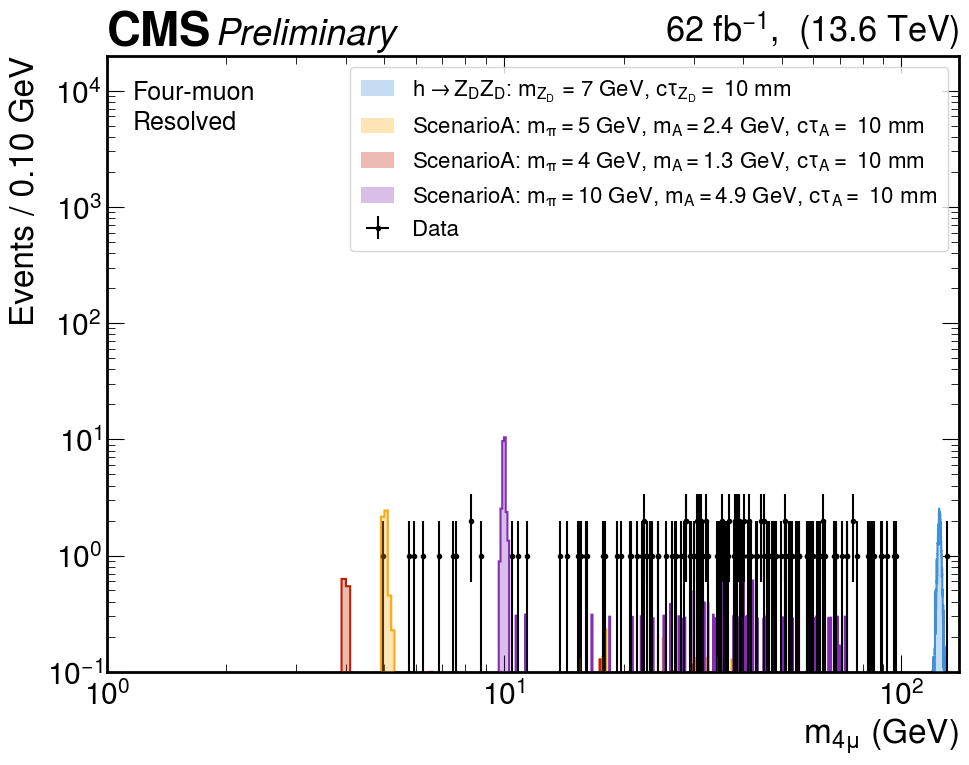

In [59]:
for hn in hnn:
    fig, ax = plt.subplots(1, 1, figsize=(11, 8))
    if not period=="allYears":
        hep.cms.label("Preliminary", data=True, year=period, com='13.6', ax=ax)
    else:
        hep.cms.label("Preliminary", data=True, year='', lumi = 62, com='13.6', ax=ax)
    # 
    # y-log scale always by default
    ax.set_yscale("log")
    ax.set_xscale("log")
    #
    # Data histogram
    dhist, dedges = getValues(histograms[hn]['Data'])
    y_err = dhist**0.5
    ddedges = []
    for v in range(0, len(dedges)-1):
        ddedges.append(dedges[v] + 0.5*(dedges[v+1] - dedges[v]))
    ax.errorbar(np.array(ddedges), dhist, yerr=y_err, xerr=0.5*(dedges[1] - dedges[0]), fmt='o', label='Data', color='k', markersize=3, zorder=5)
    ax.set_ylim(0.1, 10000*max(dhist))
    #ax.set_xlim(0.1, 140)
    #
    # Signal histograms
    for s,signal in enumerate(histograms[hn]['Signal'].keys()):
        shist, sedges = getValues(histograms[hn]['Signal'][signal])
        hep.histplot(shist, sedges, color=colors[s], label = legnames[signal], histtype="fill", ax=ax, zorder=10, alpha=0.3)
        hep.histplot(shist, sedges, color=colors[s], histtype="step", ax=ax, zorder=2)
    ax.set_ylabel('Events / %.2f GeV'%(dedges[1] - dedges[0]), fontsize=24)
    #
    #
    if "d_Dimuon" in hn:
        ax.set_xlim(0.20, 50.0)
        ax.set_xlabel(r'$m_{\mu\mu}$ (GeV)', fontsize=24)
        ax.set_xticks([0.4, 1, 3, 5, 7, 10, 20, 30, 50])
        ax.set_xticklabels(["0.4", "1", "3", "5", "7", "10", "20", "30", "50"])
        catnames = hn.split("_")
        if "excluded" in hn:
            ax.text(0.04, 0.96, "Dimuon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
            ax.text(0.04, 0.86, "Excluded", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
        elif 'inclusive' in hnn:
            ax.text(0.04, 0.96, "Dimuon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
            ax.text(0.04, 0.86, "Inclusive", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
        else:
            ax.text(0.03, 0.94, "Dimuon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
            lxybin = catnames[2]
            lxybin = (lxybin[3:]).split("to")
            ax.text(0.03, 0.89, r"$l_{{xy}} \in [{},{}]$ cm".format(lxybin[0].replace("p", ".").replace('.0', ''), lxybin[1].replace("p", ".").replace('.0', '')), fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
            if "non-pointing" not in hn:
                isobin = "Isolated" if catnames[3]=="iso1" else "Non isolated"
                ax.text(0.03, 0.84, isobin, fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
                ptbin = r"High $p_{T}^{\mu\mu}$" if catnames[4]=="pthigh" else r"Low $p_{T}^{\mu\mu}$"
                ax.text(0.03, 0.79, ptbin, fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
            else:
                ax.text(0.03, 0.84, "Non-pointing", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
        ax.axvspan(0.41, 0.50, color='lightgray', alpha=1.0, zorder=1) # Ks
        ax.axvspan(0.51, 0.59, color='lightgray', alpha=1.0, zorder=1) # Eta
        ax.axvspan(0.73, 0.83, color='lightgray', alpha=1.0, zorder=1) # rho/w
        ax.axvspan(0.96, 1.08, color='lightgray', alpha=1.0, zorder=1) # phi
        ax.axvspan(2.91, 3.27, color='lightgray', alpha=1.0, zorder=1) # JPsi
        ax.axvspan(2.89, 3.33, color='lightgray', alpha=1.0, zorder=1) # JPsi
        ax.axvspan(3.47, 3.94, color='lightgray', alpha=1.0, zorder=1) # PSi2S
        ax.axvspan(8.88, 10.85, color='lightgray', alpha=1.0, zorder=1) # Upsilon
    elif "d_FourMu_osv" in hn:
        ax.set_xscale('log')
        ax.set_xlabel(r'$m_{4\mu}$ (GeV)', fontsize=24)
        ax.text(0.03, 0.94, "Four-muon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
        fourmucat = "Overlapping"
        ax.text(0.03, 0.89, fourmucat, fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
        ax.set_xlim(1., 100.0)
    elif "d_FourMu_sep" in hn:
        ax.set_xscale('log')
        ax.set_xlabel(r'$m_{4\mu}$ (GeV)', fontsize=24)
        ax.text(0.03, 0.94, "Four-muon", fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes)
        fourmucat = "Resolved"
        ax.text(0.03, 0.89, fourmucat, fontsize=18, color='black', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes) 
        ax.set_xlim(1., 140.0)
    #
    # Added
    #ax.set_yscale('log')
    #ax.set_xlim(0.4, 50)
    #ax.set_ylim(0, 80)
    #
    #
    ax.legend(loc="upper right", fontsize=16, frameon=True)
    fig.savefig("%s_paper.png"%(hn), dpi=140) 